In [1]:
from utils import * 

%load_ext autoreload 
%autoreload 2

In [2]:
contigs_df = pd.concat([FASTAFile.from_file(path).to_df() for path in glob.glob('../data/curation/*fasta')])
# Typical overlap for de Brujin assembly graphs: 21, 33, 55, 77, 99, 127

chunk_length = 80
fasta_df = list()
for row in contigs_df.itertuples():
    if row.Index == 'Nantong_Groundwater_SRR22387873_scaffold_49841':
        continue
    seqs = np.array_split(list(row.seq), len(row.seq) // chunk_length)
    seqs = [''.join(seq) for seq in seqs]
    ids = [f'{row.Index}.{i + 1}' for i in range(len(seqs))]
    fasta_df += [{'id':id_, 'seq':seq, 'parent_id':row.Index} for id_, seq in zip(ids, seqs)]
fasta_df = pd.DataFrame(fasta_df).set_index('id')
FASTAFile.from_df(fasta_df).write('blast_nantong_groundwater_query.fasta')

In [11]:
fields = 'qseqid sseqid pident length sstart evalue bitscore qlen slen qseq sseq'
fields_map = dict()
fields_map['qseqid'] = 'query_id'
fields_map['sseqid'] = 'subject_id'
fields_map['sstart'] = 'subject_start'
fields_map['pident'] = 'percent_identity'
fields_map['evalue'] = 'e_value'
fields_map['bitscore'] = 'bit_score'
fields_map['qlen'] = 'query_length'
fields_map['slen'] = 'subject_length'
fields_map['qseq'] = 'query_seq'
fields_map['sseq'] = 'subject_seq'
fields_map['length'] = 'length'

params = dict()
params['outfmt'] = f'"6 {fields}"'
params['db'] = '/home/prichter/Documents/banfield/betazoid/data/blast/databases/Nantong_Groundwater_SRR22387873.contigs.fasta'
params['query'] = 'blast_nantong_groundwater_query.fasta'
params['out'] = 'blast_nantong_groundwater_results.tsv'

cmd = 'blastn'
for param, value in params.items():
    cmd += f' -{param} {value}'

print(cmd)
# subprocess.run(cmd, shell=True, check=True)

blast_df = pd.read_csv('blast_nantong_groundwater_results.tsv', sep='\t', names=fields.split())
blast_df = blast_df.rename(columns=fields_map)
blast_df['query_parent_id'] = [query_id.split('.')[0] for query_id in blast_df.query_id]
blast_df = blast_df[blast_df.query_parent_id != blast_df.subject_id].copy()
# blast_df = blast_df[blast_df.percent_identity > 96].copy()

false_positive_subject_ids = ['Nantong_Groundwater_SRR22387873_scaffold_133661'] # This is bacterial (CPR)
false_positive_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_67'] # Also bacterial (Chloroflexi?)
false_positive_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_8792'] # Bacterial.
false_positive_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_383'] # Bacterial. 
blast_df = blast_df[~blast_df.subject_id.isin(false_positive_subject_ids)].copy()

blastn -outfmt "6 qseqid sseqid pident length sstart evalue bitscore qlen slen qseq sseq" -db /home/prichter/Documents/banfield/betazoid/data/blast/databases/Nantong_Groundwater_SRR22387873.contigs.fasta -query blast_nantong_groundwater_query.fasta -out blast_nantong_groundwater_results.tsv


In [12]:
blast_df[blast_df.query_id.str.contains('290644') | blast_df.subject_id.str.contains('290644')]
# blast_df

,query_id,subject_id,percent_identity,length,subject_start,e_value,bit_score,query_length,subject_length,query_seq,subject_seq,query_parent_id
62,Nantong_Groundwater_SRR22387873_scaffold_29064...,Nantong_Groundwater_SRR22387873_scaffold_346753,91.304,69,526,8.720000e-19,95.3,81,1047,ATATAAAATTAATGTTAAATATGCATTTATTTTTAATTATGAACCA...,ATATAAAATTGATATTAAATATGCAATAATTTTTAATTATGAACCA...,Nantong_Groundwater_SRR22387873_scaffold_290644
302,Nantong_Groundwater_SRR22387873_scaffold_87731.3,Nantong_Groundwater_SRR22387873_scaffold_290644,93.846,65,689,6.740000e-20,99.0,81,1137,GGATTATATGATTTAGATGTTTTGAGAAAAGCCAAAAAATTAGGAT...,GGATTATATGATTTAGATGTTCTTAGAAAAGCCAAAAAATTAGGAT...,Nantong_Groundwater_SRR22387873_scaffold_87731


In [4]:



# These seem like they might be from the Methanoperedens gene. 


# false_positive_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_267820'] # Aligns to Methanoperedens. 
# false_positive_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_180849'] # Aligns to Methanoperedens. 
# false_positive_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_20278'] # Aligns to Methanoperedens. 
methanoperedens_subject_ids = ['Nantong_Groundwater_SRR22387873_scaffold_267820'] # Aligns to Methanoperedens. 
methanoperedens_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_180849'] # Aligns to Methanoperedens. 
methanoperedens_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_20278'] # Aligns to Methanoperedens. 


betazoid_subject_ids = ['Nantong_Groundwater_SRR22387873_scaffold_300679']
betazoid_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_346753']
betazoid_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_376414']
betazoid_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_87731']
betazoid_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_1350']
betazoid_subject_ids += ['Nantong_Groundwater_SRR22387873_scaffold_206400'] # Unclear. 

blast_df['subject_is_mp'] = blast_df.subject_id.isin(methanoperedens_subject_ids)


In [5]:
# from matplotlib. import LinearSegmentedColormap
from matplotlib.colors import LinearSegmentedColormap

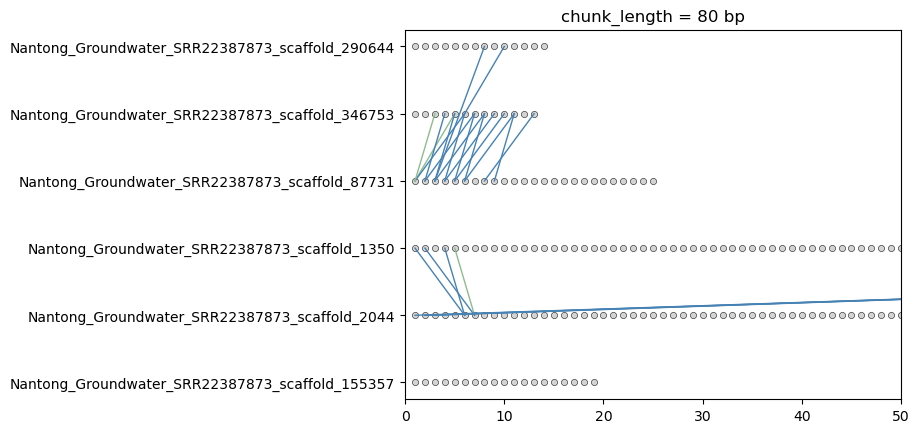

In [13]:
fig, ax = plt.subplots()

is_mp = lambda id_ : (id_ in blast_df.query_id.unique()) and np.any(blast_df[(blast_df.query_id == id_)].subject_id.isin(methanoperedens_subject_ids))

cmap = LinearSegmentedColormap.from_list('palette', ['indianred', 'lightgray', 'steelblue'])

order = ['Nantong_Groundwater_SRR22387873_scaffold_290644', 'Nantong_Groundwater_SRR22387873_scaffold_346753', 'Nantong_Groundwater_SRR22387873_scaffold_87731']
order += ['Nantong_Groundwater_SRR22387873_scaffold_1350', 'Nantong_Groundwater_SRR22387873_scaffold_2044']
order = order + [id_ for id_ in fasta_df.parent_id.unique() if (id_ not in order)]

figure_df = fasta_df.copy()
figure_df['query_id'] = figure_df.index.values 
figure_df['parent_id'] = pd.Categorical(figure_df.parent_id, ordered=True, categories=order)
figure_df = figure_df.sort_values('parent_id')
figure_df['x'] = [int(id_.split('.')[-1]) for id_ in figure_df['query_id']]
figure_df['y'] = figure_df.parent_id.map({id_:i + 1 for i, id_ in enumerate(order)}) 
# figure_df['y'] = pd.factorize(figure_df.parent_id)[0]
figure_df['is_mp'] = figure_df['query_id'].apply(is_mp)

sns.scatterplot(figure_df.sort_values('is_mp', ascending=True), x='x', y='y', s=20, facecolor='lightgray', edgecolor='black')

y = figure_df.groupby('parent_id', observed=True).y.first().to_dict()
for row in blast_df.itertuples():
    if row.subject_id not in figure_df.parent_id.unique():
        continue
    x1 = figure_df.loc[row.query_id].x
    x2 = max((row.subject_start // chunk_length), 1)# Approximate the chunk index. 
    # ax.plot([x1, x2], [y[row.query_parent_id], y[row.subject_id]], lw=0.7, color=cmap((row.percent_identity - 70) / 30))
    ax.plot([x1, x2], [y[row.query_parent_id], y[row.subject_id]], lw=1, color='darkseagreen' if (row.percent_identity > 99) else 'steelblue')

ax.set_yticks(figure_df.y.unique(), labels=figure_df.parent_id.unique())
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xlim(xmax=50, xmin=0)
ax.set_title(f'chunk_length = {chunk_length} bp')
plt.show()



